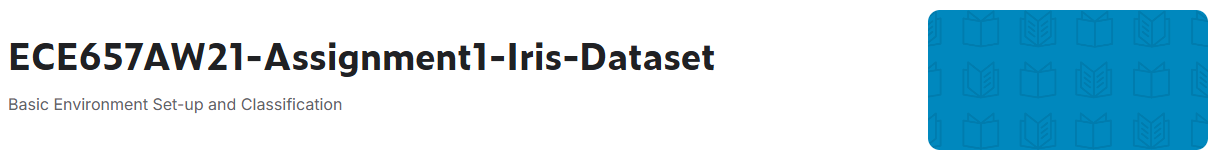

<pre>
SepalLength  :  꽃받침 길이
SepalWidth   :  꽃받침 너비
PetalLength  :  꽃잎 길이
PetalWidth   :  꽃잎 너비
Species      :  붓꽃 품종

<img width=700 src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Ft98JC%2Fbtsa6CuL7nS%2FAAAAAAAAAAAAAAAAAAAAAK32wdgXML8riDq-x9JGCuY2AwTjYVYT8-E5c199JyIX%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZedzHcoQWPMtOO8mzu493Vm48Y8%253D">

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')


#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False



#----------문제/답 분리
from sklearn.model_selection import train_test_split 


#----------군집모델
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score


#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델


#----------모델결합(Ensembles)
from sklearn.ensemble import VotingClassifier, VotingRegressor   #앙상블


#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report


#----------교차검증
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate


#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 


#----------차원 축소
from sklearn.decomposition import PCA 

# **[1] Data Load : Toy Dataset**
* https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris
* target : species
* 0 : setosa,  1 : versicolor,  2 : virginica

In [3]:
from sklearn.datasets import load_iris
tupl = load_iris(return_X_y=True, as_frame=True)
df = tupl[0]
df['target'] = tupl[1]

In [4]:
df.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


## **데이터 수정**

### 컬럼 이름 변경

In [5]:
df = df.rename(columns={'sepal length (cm)':'sl',
                      'sepal width (cm)' : 'sw',
                      'petal length (cm)': 'pl',
                      'petal width (cm)': 'pw'})

In [6]:
df.head(2)

,sl,sw,pl,pw,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sl      150 non-null    float64
 1   sw      150 non-null    float64
 2   pl      150 non-null    float64
 3   pw      150 non-null    float64
 4   target  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


* <font color='red'> 결측 없음, 글자 없음

In [8]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

# **[2] EDA(Exploratory Data Analysis)**

## hist()
* 데이터 분포도 확인(왜도, 첨도, 정규분포)

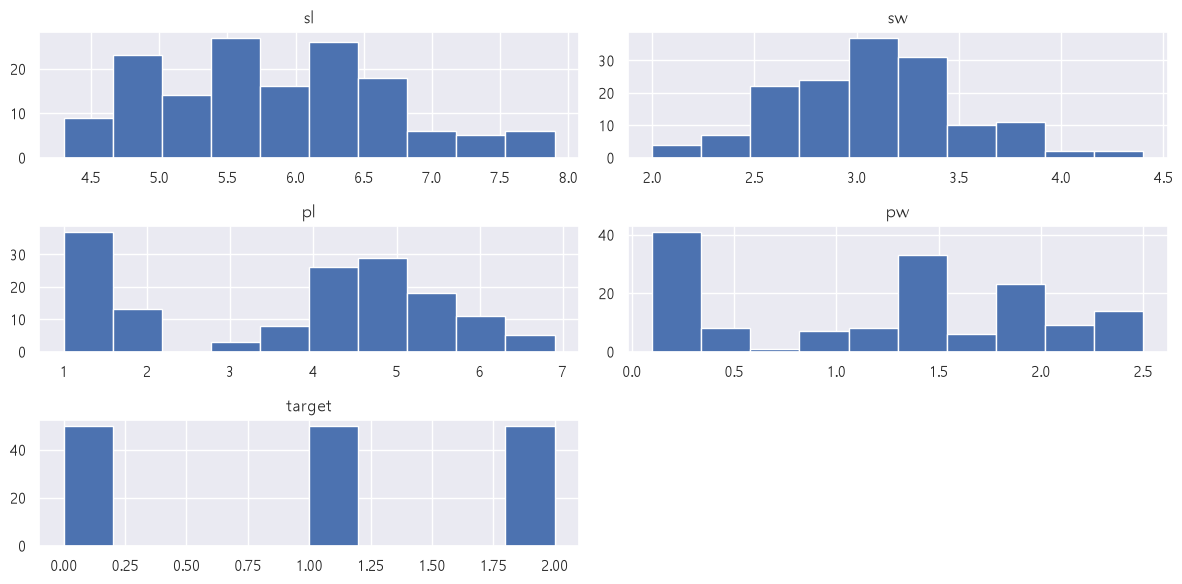

In [9]:
df.hist(figsize=(12, 6))
plt.tight_layout()
plt.show()

## pairplot()
* hist + scatter
* 데이터/컬럼이 적을 때만!

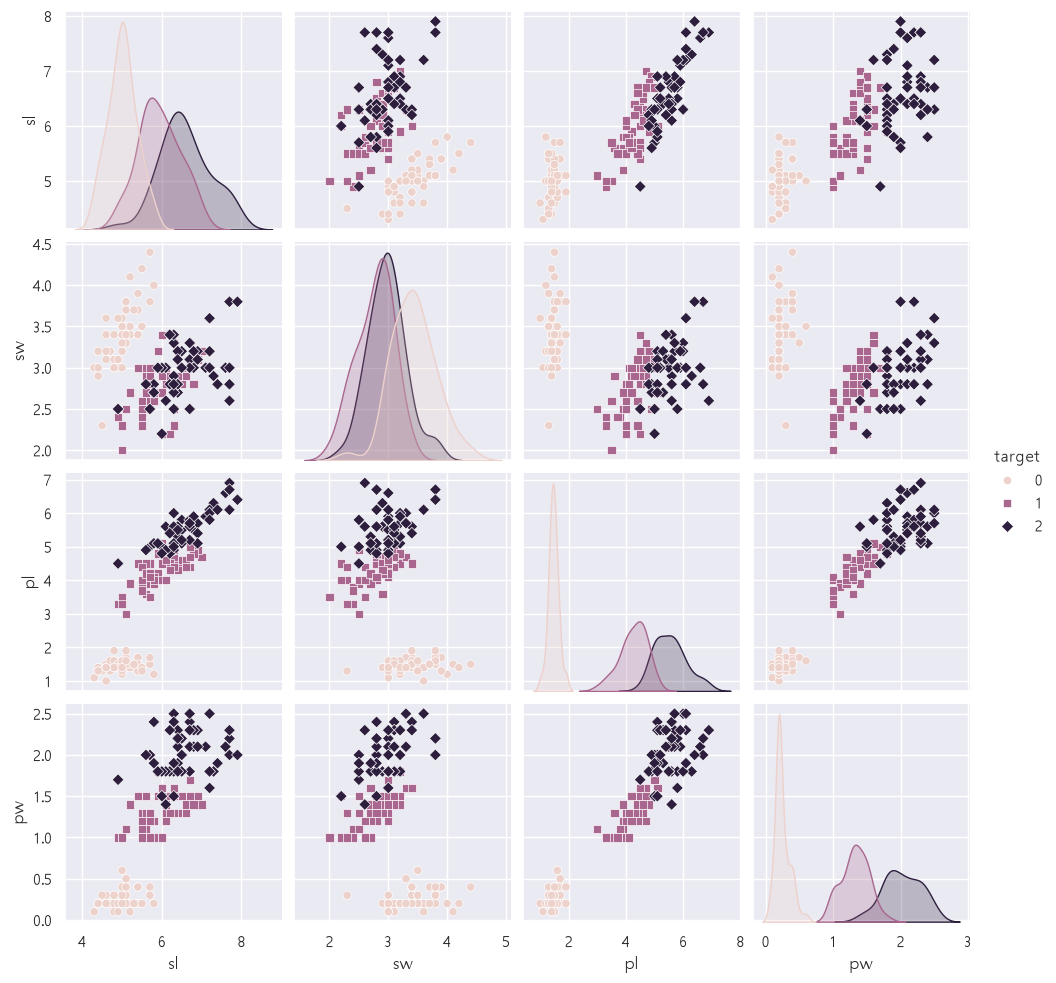

In [10]:
sns.pairplot(
    data=df,
    hue="target",     
    kind="scatter",    # ----------------비대각선에 그릴 그래프 형태 ('scatter', 'kde', 'hist', 'reg')
    diag_kind="auto",  # ----------------대각선에 그릴 그래프 형태 ('auto', 'hist', 'kde', None)
    markers=["o", "s", "D"],  # ---------클래스별 마커 모양 차별화
    )
plt.show()

> sl & sw : 겹치는 부분이 많음 <br>
> pl & pw : 확실히 구분이 잘 됨 <br> : 2개만 봐도 학습이 가능할 정도
> sl,sw & pl,pw : sl/sw가 자꾸 망침!! 계속 방해

## 상관분석

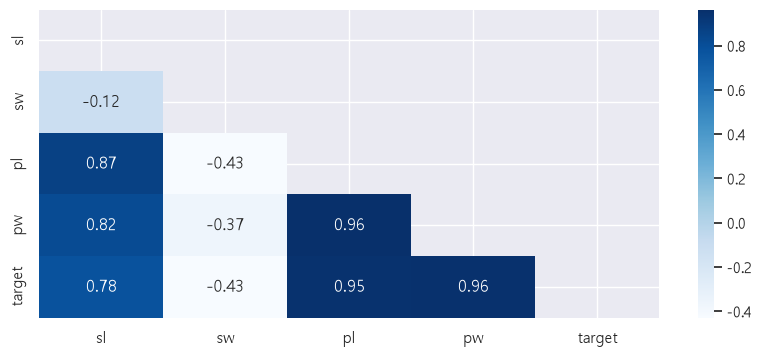

In [11]:
plt.figure(figsize=(10, 4))

mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()

> 중요도 : pw > pl > sl > sw

# **[3] 공통함수_다중분류**

## **macro & micro**
* **Macro 평균**
    - 각 클래스의 점수를 각각 계산한 후 평균 냄
    - 모든 클래스를 동일한 비중으로 평가
* **Micro 평균**
    - 모든 클래스의 값을 모두 합친 후 평균 냄
    - 샘플 수가 많은 클래스의 영향이 큼
* 특정 클래스의 비중이 많을 때(불균형 데이터) : 비중을 살린다면 micro, 동일한 비율로 계산한다면 macro
* 점수 높이려면 micro, 정확도를 높이려면 macro

## **OvO & OvR**
* OvO (One-vs-One) : 일대일 방식
  * 가능한 모든 클래스의 조합 쌍을 만들어 1:1로 비교
* OvR (One-vs-Rest/All) : 일대다 방식
  * 특정 클래스 하나와 나머지 전체를 비교

▼ 다중분류일 경우

In [12]:
def myscore333(df,  model=None, MY_TARGET="target") :
    X = df.drop(columns=['target'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234, shuffle=True,  stratify=y)
    
    if model is None : 
        model = RandomForestClassifier(n_estimators=100, random_state=1234)
    print(model.__class__.__name__)    

    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred, average='macro')
    precision = precision_score(y_test3, pred, average='macro')
    recall    = recall_score(y_test3, pred, average='macro')  
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )

    cr = classification_report(y_test3, pred)
    print(cr)


    #-------------------------------------------------proba
    proba = model.predict_proba(X_test3)
    roc = roc_auc_score(y_test3, proba, average='macro', multi_class='ovr')
    print( f"roc auc score : {roc:.4f}" )
    
    fpr = {}
    tpr = {}
    thresh ={}
    
    n_class = 3
    for i in range(n_class):    
        fpr[i], tpr[i], thresh[i] = roc_curve(y_test3, proba[:,i], pos_label=i)
        
    # plotting    
    plt.figure(figsize=(8,2))
    plt.plot(fpr[0], tpr[0], linestyle='--',color='orange', label='Class 0 vs Rest')
    plt.plot(fpr[1], tpr[1], linestyle='--',color='green' , label='Class 1 vs Rest')
    plt.plot(fpr[2], tpr[2], linestyle='--',color='blue'  , label='Class 2 vs Rest')
    plt.plot([0, 1], [0, 1], 'k-')
    plt.title("roc_curve")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR) == recall")
    plt.legend()
    plt.show()

    
    return model

# <font color=darkorange> **※점수확인※**
* acc : 0.9556  f1 : 0.9556

RandomForestClassifier
acc : 0.9556  f1 : 0.9556  precision : 0.9556  recall : 0.9556
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

roc auc score : 0.9956


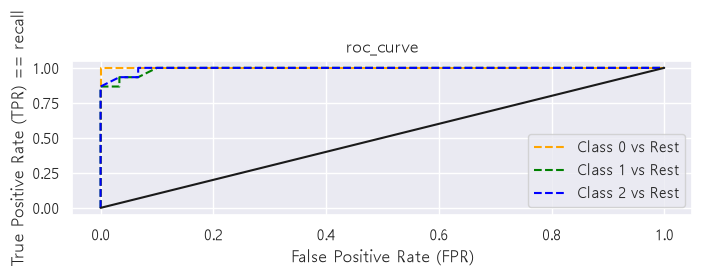

In [13]:
model = myscore333(df)

> 1종과 2종을 1개씩 틀림, 두개를 헷갈려하는걸 알 수 있음

# **[4] 군집 분석**
* 분류와 군집의 차이 : 라벨이 있냐 or 없냐, 지도학습인지 or 비지도학습인지
* 답지 없이도 학습해서 잘 나누는 게 군집
* 클러스터 헤더 간 간격이 멀수록 성능이 좋다 (구분이 잘 된다는 뜻)
* 헤더 반경 점들의 거리는 짧을수록 성능이 좋다

```python
class sklearn.cluster.KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')

class sklearn.cluster.DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)[s

class sklearn.metrics.silhouette_samples(X, labels, *, metric='euclidean', **kwds)

class sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)

<img width=1000, src="https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png">

## 답지(label) 빼기
* 비지도학습 : unsupervised training

In [14]:
df.columns

Index(['sl', 'sw', 'pl', 'pw', 'target'], dtype='str')

In [15]:
X = df[['sl', 'sw', 'pl', 'pw']]

## [4-1] KMeans
* K = Cluster Center(Header) 개수
* node = 점
* samples = 모든 점

<img width=500 src="https://miro.medium.com/v2/resize:fit:875/0*8ERlq_ZmWnZzDO83.gif">

### K=3
* n_clusters 개수
* 비지도학습(답지 없는)이기 때문에 fit/predict에 y값 없음

In [16]:
kmodel = KMeans(n_clusters=3, random_state=1234)
kmodel.fit(X)
pred_label = kmodel.predict(X)          #----------예측 아닌 거리계산 = 군집된 라벨
print(pred_label)

ch = kmodel.cluster_centers_
print(ch)          #----------cluster_centers_ : 헤더가 가지고 있는 컬럼별 값

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 1 1 1 2 1 1 1 1
 1 1 2 2 1 1 1 1 2 1 2 1 2 1 1 2 2 1 1 1 1 1 2 1 1 1 1 2 1 1 1 2 1 1 1 2 1
 1 2]
[[5.006      3.428      1.462      0.246     ]
 [6.85384615 3.07692308 5.71538462 2.05384615]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


> 왼쪽부터 sl/sw/pl/pw, 컬럼별 헤더값 <br>
> 꽃잎이 유독 짧고 얇으면 1종 <br>
> 꽃받침이 길고 꽃잎이 길고 비교적 두꺼우면 2종 <br>
> 꽃받침이 덜길고 꽃잎이 길고 비교적 얇으면 3종 <br>
> ---> 2종/3종이 구분하기 애매함

In [17]:
#---------kmodel로 거리계산한 데이터 원본 df에 합치기
df['pred_label'] = pred_label
df.head(2)

,sl,sw,pl,pw,target,pred_label
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0


### K=3인 경우 헤더들
* 150건 전체 레코드 중 3개 데이터

In [18]:
#--------헤더값 뽑아내기
ch_df = pd.DataFrame(ch, columns=['sx', 'sy', 'px', 'py'])
ch_df.head()

,sx,sy,px,py
0,5.006000,3.428000,1.462000,0.246000
1,6.853846,3.076923,5.715385,2.053846
2,5.883607,2.740984,4.388525,1.434426


#### sl&sw

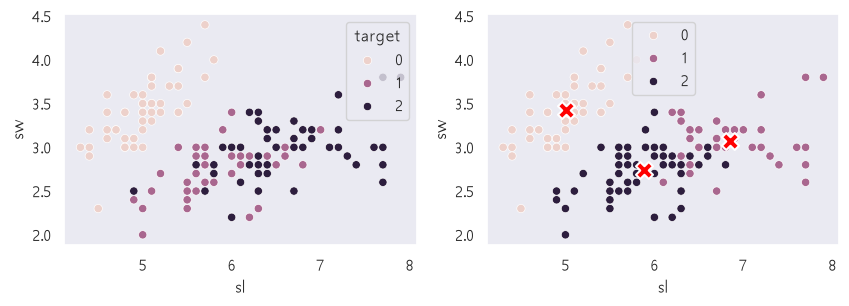

In [19]:
p, axes = plt.subplots(1,2, figsize=(10,3))
sns.scatterplot(data=df, x='sl', y='sw', hue='target', ax=axes[0])

sns.scatterplot(data=df, x='sl', y='sw', hue='pred_label', ax=axes[1])
sns.scatterplot(data=ch_df, x='sx', y='sy', ax=axes[1], marker="X", s=150,  color="red", linewidth=1.5)  #------ch(헤더값) 위치

axes[0].grid(False)
axes[1].grid(False)
plt.show()

#### pl&pw

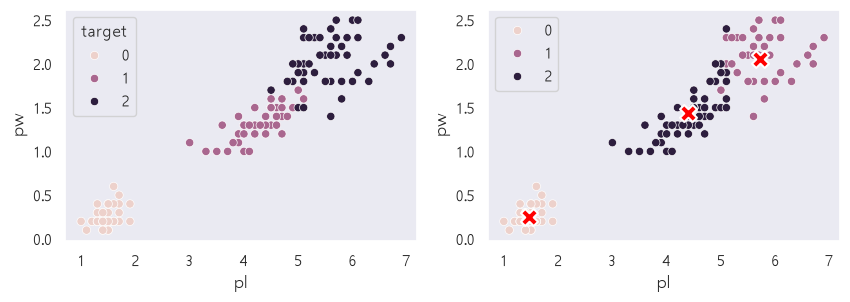

In [20]:
p, axes = plt.subplots(1,2, figsize=(10,3))
sns.scatterplot(data=df, x='pl', y='pw', hue='target', ax=axes[0])

sns.scatterplot(data=df, x='pl', y='pw', hue='pred_label', ax=axes[1])
sns.scatterplot(data=ch_df, x='px', y='py', ax=axes[1],             #------ch(헤더값) 위치
                marker="X", s=150,  color="red", linewidth=1.5)     #------헤더값 마커

axes[0].grid(False)
axes[1].grid(False)
plt.show()

> 좌 답지(원본) / 우 예측 <br>
> KMeans 특성에 맞춰 단면으로 짤라버림

### K값 튜닝
* **inertia_** : ch(헤더)와 ch 주변 모든 점(데이터)들의 거리 제곱 합
* sum of squared distances of samples to their closet cluster center
* 응집도가 높다(주변 점들이 밀집되어있다) : 값이 작을수록 좋다

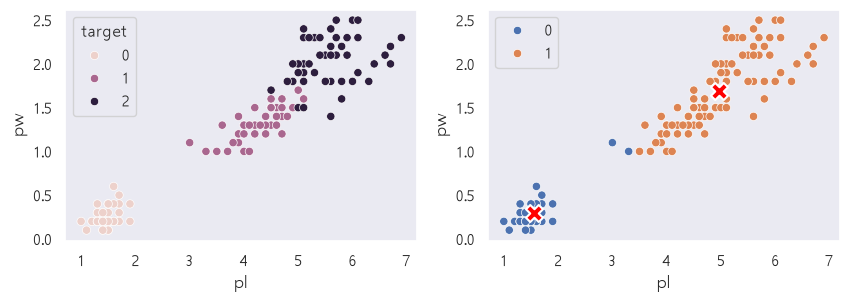

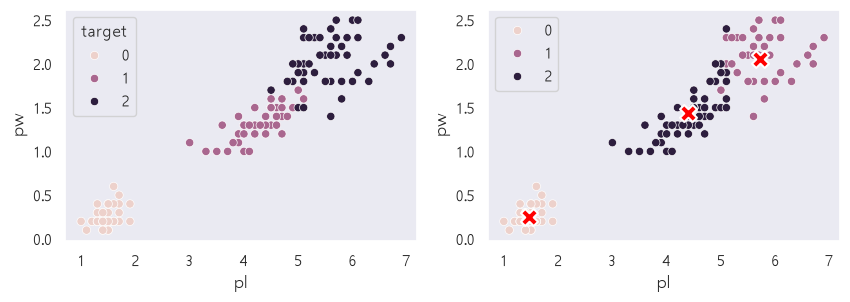

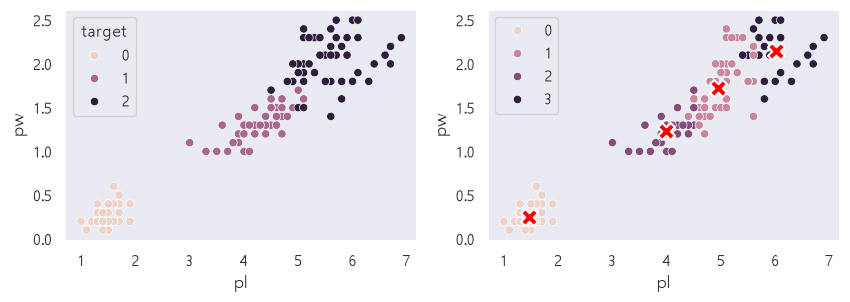

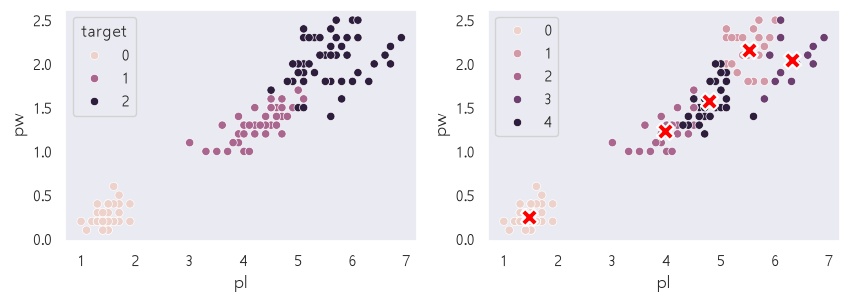

In [21]:
inertia_list = []

for my_k in [2,3,4,5]:
    kmodel = KMeans(n_clusters=my_k, random_state=1234)
    kmodel.fit(X)
    pred_label = kmodel.predict(X)

    inertia_list.append(kmodel.inertia_)
    
    ch = kmodel.cluster_centers_
    df['pred_label'] = pred_label
    ch_df = pd.DataFrame(ch, columns=['sx', 'sy', 'px', 'py'])

    p, axes = plt.subplots(1,2, figsize=(10,3))
    sns.scatterplot(data=df, x='pl', y='pw', hue='target', ax=axes[0])
    
    sns.scatterplot(data=df, x='pl', y='pw', hue='pred_label', ax=axes[1])
    sns.scatterplot(data=ch_df, x='px', y='py', ax=axes[1],             #------ch(헤더값) 위치
                    marker="X", s=150,  color="red", linewidth=1.5)     #------헤더값 마커
    
    axes[0].grid(False)
    axes[1].grid(False)
    plt.show()

### 적정 K값 찾기 : 엘보차트 
* 군집개수 : 3개

[152.34795176035792, 78.85566582597731, 57.38387326549491, 46.47223015873016]


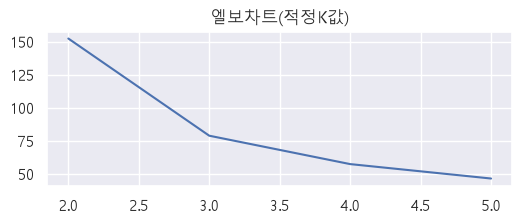

In [22]:
print(inertia_list)

plt.figure(figsize=(6,2))
plt.plot([2,3,4,5], inertia_list)
plt.title('엘보차트(적정K값)')
plt.show()

> K값을 늘릴수록 inertia(응집도)는 높아진다 <br>
> <u> 엘보차트의 꺾인점이 적정 K값

### Silhouette Coeffficient / Silhouette Score
* **1) Coef 계산 함수_silhouette_samples** : samples(모든점)의 coef값((b-a) / max(a,b))을 계산하는 함수
* **2) 150개_Silhouette Coefficient(실루엣 계수)** : 모든 node(점)들이 (b-a) / max(a,b) 계산
  * a : intra-cluster distance, 클러스터 내부 samples(모든점)의 거리 평균 (가까울수록 좋다)
  * b : nearest-cluster distance, 가장 가까운 클러스터 헤더와의 거리 (멀수록 좋다)
  <font color=gray> -------------------------------------------------------------------------------------------------
  * -1 : 잘못된 군집
  * 0 : 겹쳐있음
  * 1 : 최상
  <font color=gray> -------------------------------------------------------------------------------------------------
* **3) 1개 평균값_Silhouette Score(실루엣 점수)** : 모든 node(점)들의 Silhouette Coef(실루엣 계수) 합의 평균
* <font color=blue> **---> 샘플을 이용해 코프를 계산하고, 코프의 평균을 통해 평균을 내어 점수를 계산한다**

```python
class sklearn.metrics.silhouette_samples(X, labels, *, metric='euclidean', **kwds)
class sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)

In [23]:
kmodel = KMeans(n_clusters=3, random_state=1234)
kmodel.fit(X)
pred_label = kmodel.predict(X)
df['pred_label'] = pred_label

* 방법1) scoef150 = silhouette_samples() 후 scoef150.mean()

In [24]:
scoef150 = silhouette_samples(df[['sl', 'sw', 'pl', 'pw']], df['pred_label'])
print(scoef150[:10])      #-----범위 지정 안 하면 데이터 개수만큼(150개 나옴)

[0.85258191 0.8149163  0.82879659 0.80435199 0.84891774 0.7477614
 0.82109757 0.8534934  0.75127806 0.82475199]


In [25]:
df['scoef150'] = scoef150
df.head(3)

,sl,sw,pl,pw,target,pred_label,scoef150
0,5.1,3.5,1.4,0.2,0,0,0.852582
1,4.9,3.0,1.4,0.2,0,0,0.814916
2,4.7,3.2,1.3,0.2,0,0,0.828797


In [26]:
print( np.mean(scoef150) )    #-------- 같은 문법, sscore == np.mean(scoef) 같은 값!

0.5511916046195919


* 방법2) silhouette_score()

In [27]:
sscore = silhouette_score(df[['sl', 'sw', 'pl', 'pw']], df['pred_label'])
print( sscore )

0.5511916046195919


### 군집별 silhouette_score
* groupby('pred_label')['scoef150'].mean() : 군집별 거리 평균 (구분되는 정도)
* <font color=blue> **---> 군집은 정답이 없기 때문에 거리 계산으로 점수를 냄**

In [28]:
df.groupby('pred_label')['scoef150'].mean()

pred_label
0    0.797604
1    0.436842
2    0.422323
Name: scoef150, dtype: float64

> 0종은 나머지와 확연히 다름 <br>
> 1종/2종은 수치가 비슷함

## **[4-2] 표준화(StandardScaler)**
* Scaler : StandardScaler, MinMaxScaler, AbsoluteScaler
* StandardScaler : 평균 0, 편차 1 == 표준정규분포 범위로 데이터 축소 == 표준화
* 연속형 피쳐에 주로 사용

In [29]:
ss = StandardScaler()
ss.fit(df[['sl', 'sw', 'pl', 'pw']])
scale_res = ss.transform(df[['sl', 'sw', 'pl', 'pw']])
scale_res[:3]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ]])

## **[4-3] PCA(Principal Component Analysis) : 주성분 분석**
* **군집에서 시각화는 PCA(차원축소) 필수**
* **일반적으로 표준화(StandardScaler)를 병행 : 큰 수치에 더 민감하게 반응하기 때문**
* 피쳐보다 하나 적게까지 축소 가능 (100% 불가능)

<img width=1000, src="https://i.imgur.com/Uv2dlsH.gif">

```python
class sklearn.decomposition.PCA(n_components=None, *, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto', random_state=None)

* **공분산 행렬 내적 : 고유값(주성분), 고유벡터(PC)**
    * PC1 == 고유벡터1 == 고유값을 가장 많이 포함하는(분산이 가장 큰) 선
    * PC2 == 고유벡터2 == PC1과 직교
    * PCn == 고유벡터n == PC(n-1)과 직교
* **고유값(주성분) 분석**
    * 원하는 설명력(explained_variance_)을 가지려면 몇 차까지 축소해야 하는지
    * 정보력(투여된 양(PC)이 얼마나 되는지)

In [30]:
#-----------원본
df[['sl','sw', 'pl', 'pw']].head(3)

,sl,sw,pl,pw
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


### PCA

In [31]:
#-----------3차로 줄인 투영값
pca = PCA(n_components=3 , random_state=1234)
pca_res = pca.fit_transform(df[['sl','sw', 'pl', 'pw']])
pca_res[:3]

array([[-2.68412563,  0.31939725, -0.02791483],
       [-2.71414169, -0.17700123, -0.21046427],
       [-2.88899057, -0.14494943,  0.01790026]])

In [32]:
#-----------설명력 확인
print( f"개별 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )

개별 PC 설명력 : [0.92461872 0.05306648 0.01710261]
PCA 전체 설명력 : 0.995


In [33]:
#-----------2차로 줄인 투영값
pca = PCA(n_components=2 , random_state=1234)
pca_res = pca.fit_transform(df[['sl','sw', 'pl', 'pw']])
pca_res[:3]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [34]:
#-----------설명력 확인
print( f"개별 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )

개별 PC 설명력 : [0.92461872 0.05306648]
PCA 전체 설명력 : 0.978


> 피쳐 2개로 축소 시 데이터 손실이 더 적다 (0.978 보존)

### **표준화 적용 전 PCA**

[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]]
개별 PC 설명력 : [0.92461872 0.05306648]
PCA 전체 설명력 : 0.978


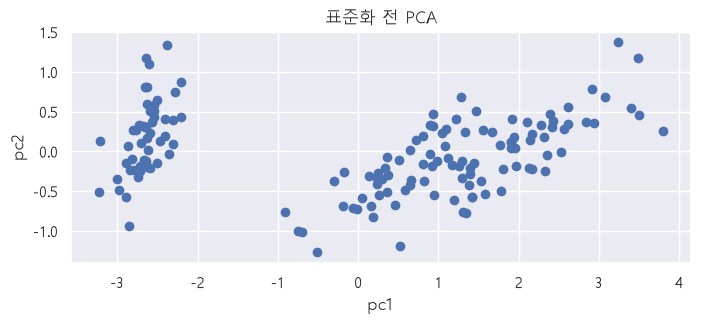

In [35]:
pca = PCA(n_components=2 , random_state=1234)
pca_res = pca.fit_transform(df[['sl','sw', 'pl', 'pw']])
print(pca_res[:3])
print( f"개별 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )

plt.figure(figsize=(8,3))
plt.scatter(x=pca_res[:, 0], y=pca_res[:, 1])
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('표준화 전 PCA')
plt.show()

### **표준화 적용 PCA**

[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]]
개별 PC 설명력 : [0.72962445 0.22850762]
PCA 전체 설명력 : 0.958


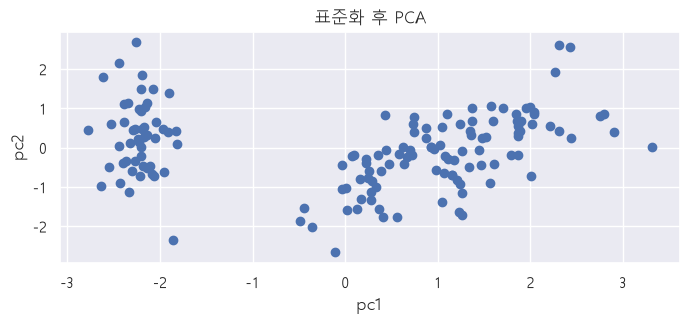

In [36]:
ss = StandardScaler()
ss.fit(df[['sl', 'sw', 'pl', 'pw']])
scale_res = ss.transform(df[['sl', 'sw', 'pl', 'pw']])
scale_res[:3]

pca = PCA(n_components=2 , random_state=1234)
pca_res = pca.fit_transform(scale_res)
print(pca_res[:3])
print( f"개별 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )
# 시각화에 사용할 X/y 데이터 : (x=pca_res[:, 0], y=pca_res[:, 1])

plt.figure(figsize=(8,3))
plt.scatter(x=pca_res[:, 0], y=pca_res[:, 1])
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('표준화 후 PCA')
plt.show()

## [4-4] 평가 시각화 공통함수

In [41]:
import matplotlib.cm as cm

def view_chart(X, range_n_clusters=[2, 3, 4, 5, 6]):
    for n_clusters in range_n_clusters:
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(14, 5)

        
        # --------------------------------표준화 부분------------------------------------
        ss = StandardScaler()
        ss.fit(df[['sl', 'sw', 'pl', 'pw']])
        scale_res = ss.transform(df[['sl', 'sw', 'pl', 'pw']])
        scale_res[:3]
        
        pca = PCA(n_components=2 , random_state=1234)
        pca_res = pca.fit_transform(scale_res)
        
        print( f"개별 PC 설명력 : {pca.explained_variance_ratio_}" )
        print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )
        # 시각화에 사용할 X/y 데이터 : (x=pca_res[:, 0], y=pca_res[:, 1])

        X = pd.DataFrame(pca_res, columns=['sPC1', 'sPC2'])   #---------스케일링 후 PCA된 데이터를 X에
        # -------------------------------------------------------------------------------
        # 원본 : X = df[['sl', 'sw', 'pl', 'pw']]
        # -------------------------------------------------------------------------------

        
        clusterer = KMeans(n_clusters=n_clusters, random_state=10)
        cluster_labels = clusterer.fit_predict(X)

        silhouette_avg = silhouette_score(X, cluster_labels)
        print(
            "For n_clusters =", n_clusters,
            "The average silhouette_score is :",silhouette_avg,
        )

        # ------------------ 차트 -------------------------
        sample_silhouette_values = silhouette_samples(X, cluster_labels)
        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(
            X.iloc[:, 0], X.iloc[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="white",
            alpha=1,
            s=200,
            edgecolor="k",
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

    plt.show()

개별 PC 설명력 : [0.72962445 0.22850762]
PCA 전체 설명력 : 0.958
For n_clusters = 2 The average silhouette_score is : 0.6145202036230449
개별 PC 설명력 : [0.72962445 0.22850762]
PCA 전체 설명력 : 0.958
For n_clusters = 3 The average silhouette_score is : 0.5049971595655939
개별 PC 설명력 : [0.72962445 0.22850762]
PCA 전체 설명력 : 0.958
For n_clusters = 4 The average silhouette_score is : 0.44336898765188504
개별 PC 설명력 : [0.72962445 0.22850762]
PCA 전체 설명력 : 0.958
For n_clusters = 5 The average silhouette_score is : 0.42161970775531993


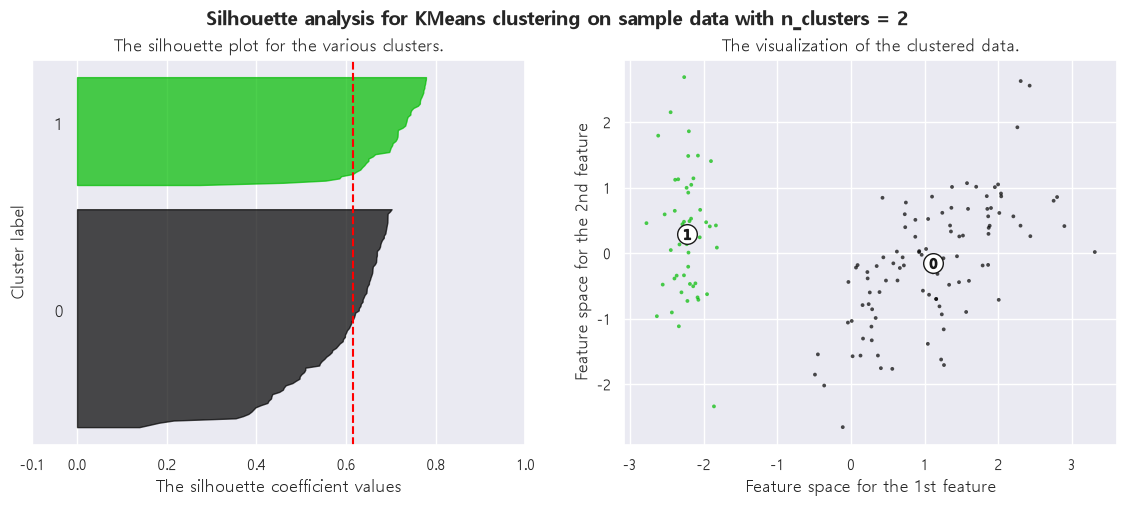

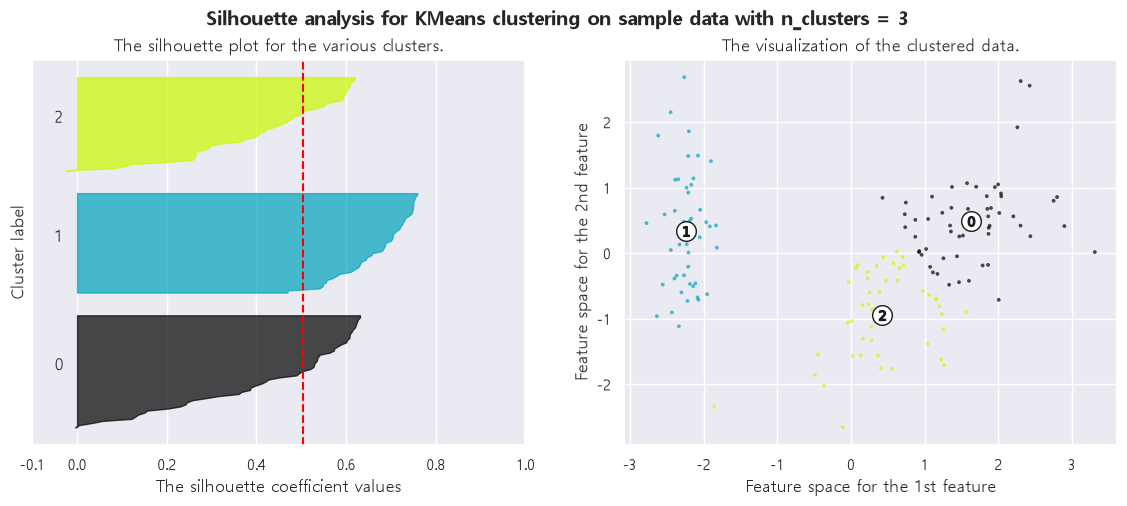

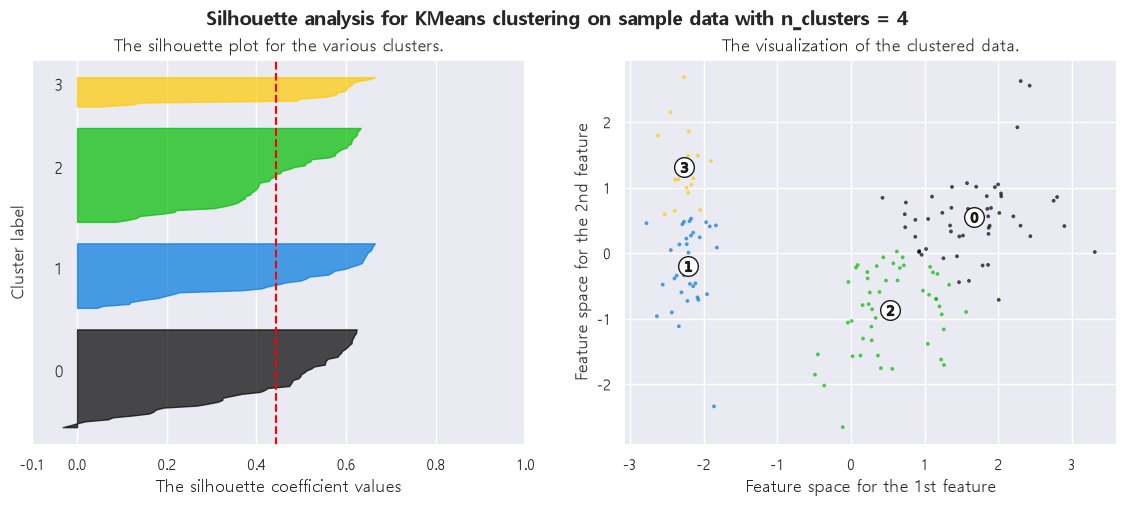

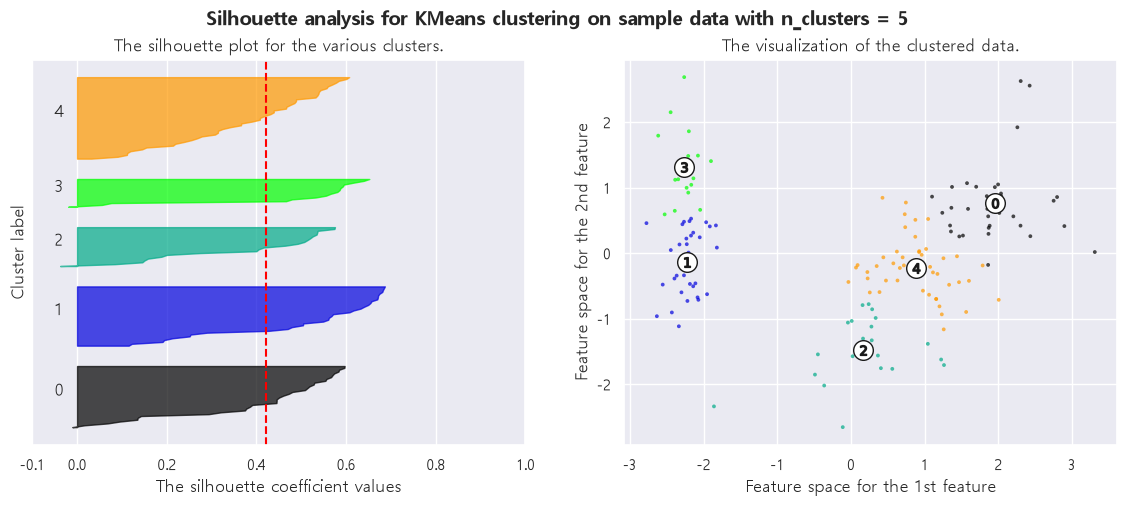

In [42]:
view_chart(X, range_n_clusters=[2, 3, 4, 5])

> 표준화 전에 비해 기준선을 많이 넘어옴 <br>
> 겹치는 부분도 없어짐

## [4-5] DBSCAN
* Density-Based Spatial Clustering of Applications with Noise
* 데이터의 밀도를 기반으로 군집을 묶고 이상치를 찾아내는 <u> 밀도 기반 클러스터링 알고리즘
* **핵심점(Core Point)**: 반경 내에 지정된 최소 점 개수 이상의 이웃이 있는 점
* **경계점(Border Point)**: 핵심점의 반경 내에 있지만, 자기 자신의 반경 내의 점 개수는 기준에 못 미치는 점
* **잡음점 (Noise Point)**: 핵심점도 아니고 경계점도 아닌 이상치

```python
class sklearn.cluster.DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
# ----- Core Point 기준 ---- eps=반경 0.5 안에, min_samples=최소 점 개수 5개

### eps=0.5, min_sample=5

<img width=600 src="https://media.geeksforgeeks.org/wp-content/uploads/20250912174514326431/4.webp">

In [53]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
pred_label2 = dbscan.fit_predict(X)
#print(pred_label2)

df['pred_label2'] = pred_label2

scoef150 = silhouette_samples(df[['sl', 'sw', 'pl', 'pw']], df['pred_label2'])
df['scoef150_db'] = scoef150
print(scoef150.mean())

sscore = silhouette_score(df[['sl', 'sw', 'pl', 'pw']], df['pred_label2'])
print( sscore )

0.48603419703456857
0.48603419703456857


#### **군집 수 : 2개**

In [48]:
#중복 제거 : set
print( set(pred_label2) )

{np.int64(0), np.int64(1), np.int64(-1)}


In [50]:
# predict 값에서 -1(이상치)을 뺀 클러스터 개수
n_clusters = len(set(pred_label2)) - (1 if -1 in pred_label2 else 0)
print(f"클러스터 개수: {n_clusters}")

클러스터 개수: 2


In [54]:
df.head(2)

,sl,sw,pl,pw,target,pred_label,scoef150,pred_label2,scoef150_db
0,5.1,3.5,1.4,0.2,0,0,0.852582,0,0.876795
1,4.9,3.0,1.4,0.2,0,0,0.814916,0,0.842545


### 군집별 silhouette_score
* groupby('pred_label')['scoef150'].mean() : 군집별 거리 평균 (구분되는 정도)
* <font color=blue> **---> 군집은 정답이 없기 때문에 거리 계산으로 점수를 냄**

In [55]:
df.groupby('pred_label2')['scoef150_db'].mean()

pred_label2
-1   -0.259664
 0    0.831133
 1    0.435642
Name: scoef150_db, dtype: float64

> 실제로 실루엣스코어에서도 군집 수 2개로 찍힘 (-1은 아웃라이어) <br>
> KMeans는 3개로 답함

#### 잡음노드(outlier) : 17개

In [56]:
df[df['pred_label2']==-1].shape

(17, 9)

### 최적의 eps찾기

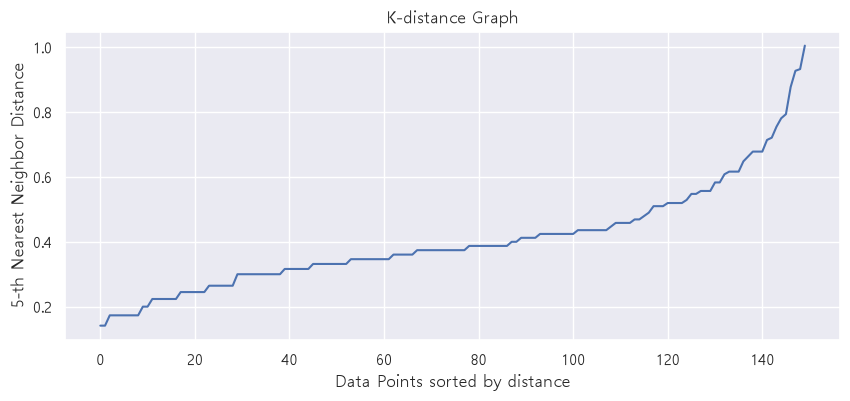

In [61]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors 

# 1. min_samples 후보군 설정 (예: 5) 
k = 5
neighbors = NearestNeighbors(n_neighbors=k) 
neighbors_fit = neighbors.fit(X) 

# 2. 모든 포인트의 k번째 이웃까지의 거리 계산 
distances, indices = neighbors_fit.kneighbors(X) 

# 3. 거리 데이터를 오름차순 정렬 (가장 먼 이웃 거리만 추출) 
sort_distances = np.sort(distances[:, k-1], axis=0) 

# 4. 그래프 시각화 
plt.figure(figsize=(10, 4)) 
plt.plot(sort_distances) 
plt.title("K-distance Graph") 
plt.xlabel("Data Points sorted by distance") 
plt.ylabel(f"{k}-th Nearest Neighbor Distance") 
plt.grid(True)
plt.show()

#### eps, min_samples 튜닝

In [66]:
for my_eps in [0.4, 0.5] :
    for my_samples in [5, 6, 7, 8, 9, 10] :
        
        dbscan = DBSCAN(eps=my_eps, min_samples=my_samples)
        pred_label2 = dbscan.fit_predict(X)
        df['pred_label2'] = pred_label2
        
        sscore = silhouette_score(df[['sl', 'sw', 'pl', 'pw']], df['pred_label2'])
        print( f"{my_eps} {my_samples} {sscore:.4f}" )

0.4 5 0.2779
0.4 6 0.2779
0.4 7 0.1992
0.4 8 0.1701
0.4 9 0.1644
0.4 10 0.1214
0.5 5 0.4860
0.5 6 0.4772
0.5 7 0.4643
0.5 8 0.4503
0.5 9 0.4316
0.5 10 0.4227


> 최적 : eps 0.4, min_samples 10 <br>
> 0.1214 <br>
> min_saples : 피쳐 수 * 2까지가 최대  ---> min샘플 8로 고정

### 평가 시각화 공통함수

In [72]:
def view_chart_dbscan(df, my_eps=[0.4, 0.5], min_samples=8):
    # ---------------------- 데이터 전처리 및 PCA -----------------------------
    ss = StandardScaler()
    scale_res = ss.fit_transform(df)
    
    pca = PCA(n_components=2, random_state=1234)
    pca_res = pca.fit_transform(scale_res)
    
    print(f"각각의 PC 설명력 : {pca.explained_variance_ratio_}")
    print(f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}\n")   
    
    X_pca = pd.DataFrame(pca_res, columns=["sPC1","sPC2"])
    # ---------------------------------------------------------------------------

    for eps in my_eps:
        # DBSCAN 모델 생성 및 예측
        clusterer = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = clusterer.fit_predict(X_pca)

        # 노이즈를 제외한 순수 클러스터 개수 계산
        unique_labels = set(cluster_labels)
        n_clusters = len(unique_labels) - (1 if -1 in cluster_labels else 0)

        # 에러 방지 예외처리: 클러스터가 2개 이상 생기지 않으면 실루엣 점수를 계산할 수 없음
        if n_clusters < 2:
            print(f"For eps = {eps}: 군집 실패")
            continue

        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(8, 4)

        # 실루엣 점수는 노이즈(-1)를 제외하고 계산하는 것이 일반적입니다.
        non_noise_mask = cluster_labels != -1
        silhouette_avg = silhouette_score(X_pca[non_noise_mask], cluster_labels[non_noise_mask])
        
        # 노이즈 비율 계산
        noise_ratio = np.sum(cluster_labels == -1) / len(cluster_labels)
        print(f"For eps = {eps} -> 찾아낸 클러스터 수: {n_clusters} | 평균 실루엣 점수: {silhouette_avg:.3f} | 노이즈 비율: {noise_ratio*100:.1f}%")

        # 전체 데이터에 대한 실루엣 샘플 값 계산
        sample_silhouette_values = np.zeros(len(cluster_labels))
        # 노이즈가 아닌 데이터만 실루엣 값 계산 후 삽입
        sample_silhouette_values[non_noise_mask] = silhouette_samples(X_pca[non_noise_mask], cluster_labels[non_noise_mask])

        y_lower = 10
        # 노이즈(-1)를 제외한 실제 정수 클러스터 라벨들 순회
        valid_labels = sorted([lbl for lbl in unique_labels if lbl != -1])
        
        for idx, i in enumerate(valid_labels):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(idx) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_yticks([])  
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot: 데이터 산점도 시각화
        # 노이즈(-1) 데이터는 검은색(k)으로 표현하고, 일반 군집은 컬러 배치
        colors = np.zeros((len(cluster_labels), 4)) # RGBA 배열
        for idx, label in enumerate(cluster_labels):
            if label == -1:
                colors[idx] = [0, 0, 0, 0.5] # 검은색, 투명도 0.5 (노이즈 표시)
            else:
                cluster_idx = valid_labels.index(label)
                colors[idx] = cm.nipy_spectral(float(cluster_idx) / n_clusters)

        ax2.scatter(
            X_pca.iloc[:, 0], X_pca.iloc[:, 1], marker=".", s=40, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # [변경점] DBSCAN은 중심점이 없으므로, 군집별 데이터의 평균 좌표 위치에 라벨 텍스트만 표시
        for i in valid_labels:
            cluster_points = X_pca[cluster_labels == i]
            center_x = cluster_points.iloc[:, 0].mean()
            center_y = cluster_points.iloc[:, 1].mean()
            
            # 하얀 원 안에 숫자를 써서 중심부 표현
            ax2.scatter(center_x, center_y, marker="o", c="white", alpha=0.8, s=150, edgecolor="k")
            ax2.scatter(center_x, center_y, marker=f"${i}$", alpha=1, s=40, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            f"Silhouette analysis for DBSCAN clustering with eps = {eps}, min_samples = {min_samples}",
            fontsize=12,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

각각의 PC 설명력 : [0.72962445 0.22850762]
PCA 전체 설명력 : 0.958

For eps = 0.4 -> 찾아낸 클러스터 수: 2 | 평균 실루엣 점수: 0.680 | 노이즈 비율: 18.0%


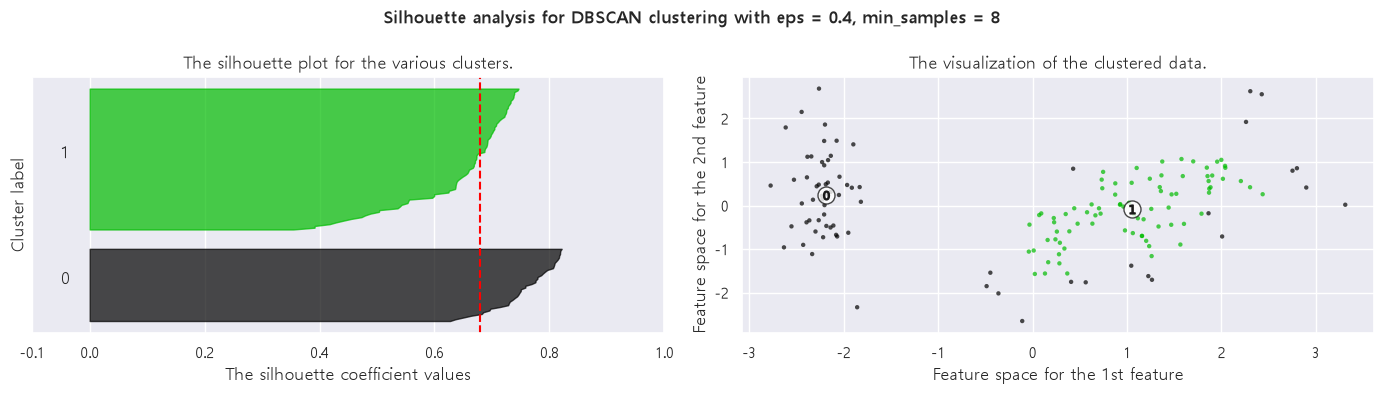

For eps = 0.5 -> 찾아낸 클러스터 수: 2 | 평균 실루엣 점수: 0.667 | 노이즈 비율: 10.7%


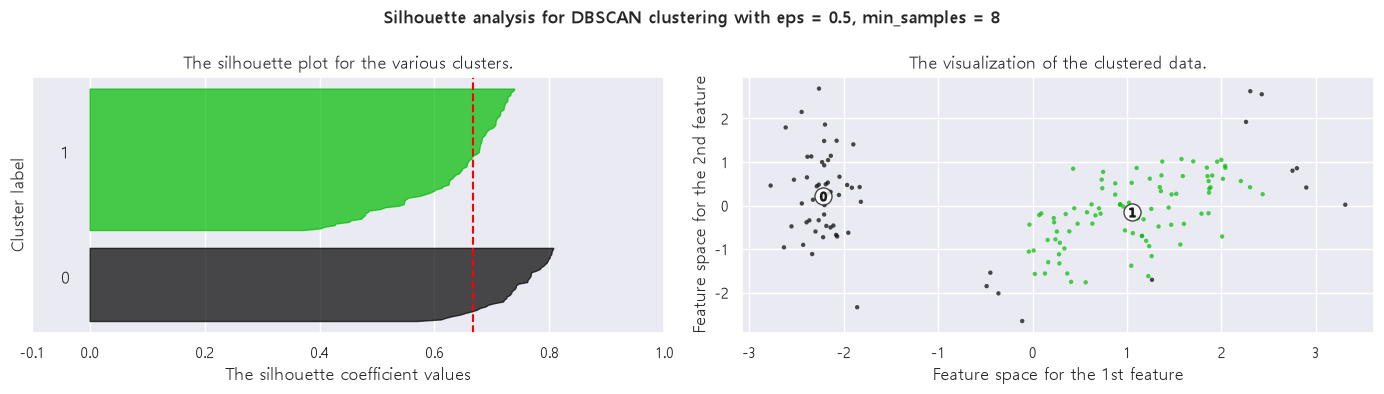

In [70]:
view_chart_dbscan(df[['sl','sw','pl','pw']])

> <font color=red> **우리 모델에 DBSCAN은 적합하지 않다** <br> </font>
> KMeans는 선형으로 뚝 잘라서 군집 <br>
> DBSCAN은 초평면을 이용해서 군집 <br>